In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
transactions = pd.read_excel(r"D:\Forage\QVI_transaction_data.xlsx")
transactions

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [4]:
transactions.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [5]:
transactions.shape

(264836, 8)

In [6]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [7]:
transactions.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [8]:
transactions.duplicated().sum()

1

In [9]:
#Removing duplicates
transactions=transactions.drop_duplicates()

In [10]:
#Checking for duplicates again
transactions.duplicated().sum()

0

In [11]:
transactions['PROD_QTY'].describe()

count    264835.000000
mean          1.907308
std           0.643655
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [12]:
transactions = transactions[transactions['PROD_QTY'] < 20]

In [13]:
transactions['PROD_QTY'].describe()

count    264833.000000
mean          1.905812
std           0.343437
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           5.000000
Name: PROD_QTY, dtype: float64

##### PROD_QTY had a maximum value of 200 which is unrealistic for normal chip purchases.
##### Transactions with quantity >=20 were treated as outliers and removed.

In [14]:
#Converting the date column to datetime format
transactions["DATE"] = pd.to_datetime(transactions["DATE"], unit="D", origin="1899-12-30")

In [15]:
transactions["DATE"].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]

In [16]:
## Creating UNIT_PRICE to check pricing consistency across transactions
transactions['UNIT_PRICE'] = transactions['TOT_SALES'] / transactions['PROD_QTY']

In [17]:
transactions['UNIT_PRICE'].describe()

count    264833.000000
mean          3.824632
std           1.109527
min           1.320000
25%           3.000000
50%           3.800000
75%           4.600000
max           6.500000
Name: UNIT_PRICE, dtype: float64

In [18]:
## Checking whether chip prices fall within a reasonable range
transactions['UNIT_PRICE'].unique()

array([3.  , 2.1 , 1.45, 4.6 , 5.1 , 5.7 , 3.6 , 3.9 , 4.6 , 1.7 , 3.3 ,
       2.3 , 3.8 , 5.4 , 2.7 , 3.7 , 4.4 , 2.6 , 3.25, 2.9 , 3.1 , 4.2 ,
       4.3 , 1.5 , 1.9 , 5.9 , 4.4 , 2.8 , 1.8 , 1.9 , 6.5 , 2.4 , 3.8 ,
       3.3 , 5.4 , 2.7 , 5.1 , 3.7 , 1.85, 1.35, 5.9 , 1.44, 2.8 , 1.84,
       2.16, 1.65, 1.32, 2.2 , 2.3 , 1.48, 2.55, 2.04])

In [19]:
transactions["PROD_NAME"].str.contains("salsa", case=False).sum()

18094

##### UNIT_PRICE ranges from ~1.32 to 6.50 which is reasonable for chip products.
##### However some products contain "salsa" which are not chips and should be removed.

In [20]:
transactions['PROD_NAME'].sample(10, random_state=42)

81873             Kettle Honey Soy    Chicken 175g
217661    Infuzions Thai SweetChili PotatoMix 110g
224332           Tostitos Smoked     Chipotle 175g
241751         Pringles Chicken    Salt Crips 134g
178760           Smiths Crinkle      Original 330g
53873     Kettle Tortilla ChpsHny&Jlpno Chili 150g
14346                Tostitos Splash Of  Lime 175g
34587              Tostitos Lightly    Salted 175g
144505      Cobs Popd Sour Crm  &Chives Chips 110g
246625     Doritos Corn Chips  Cheese Supreme 170g
Name: PROD_NAME, dtype: object

In [21]:
transactions = transactions[~transactions["PROD_NAME"].str.contains("salsa", case=False)]

##### Removing salsa products since analysis focuses only on chips category

In [22]:
transactions.shape

(246739, 9)

In [23]:
# Extracting pack size (grams) from product name for size preference analysis
transactions["PACK_SIZE"] = transactions["PROD_NAME"].str.extract("(\d+)").astype(int)

In [24]:
# Extracting brand name from product name for brand preference analysis
transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0]

In [25]:
transactions[["PROD_NAME","BRAND","PACK_SIZE"]].head(10)

,PROD_NAME,BRAND,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,Natural,175
1,CCs Nacho Cheese 175g,CCs,175
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths,170
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle,150
6,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths,330
7,Grain Waves Sweet Chilli 210g,Grain,210
8,Doritos Corn Chip Mexican Jalapeno 150g,Doritos,150
9,Grain Waves Sour Cream&Chives 210G,Grain,210
10,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths,330


In [26]:
# Loading the purhcase behaviour data
customers = pd.read_csv("QVI_purchase_behaviour.csv")
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [27]:
customers.shape

(72637, 3)

In [28]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [29]:
customers.isnull().sum()


LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [30]:
customers.duplicated().sum()

0

In [31]:
# Merging transaction dataset with customer dataset using loyalty card number
data = pd.merge(transactions, customers, on="LYLTY_CARD_NBR", how="left")

In [32]:
data.shape

(246739, 13)

In [33]:
data.sample(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,UNIT_PRICE,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
108220,2018-07-13,250,250022,251565,62,Pringles Mystery Flavour 134g,2,7.4,3.7,134,Pringles,OLDER SINGLES/COUPLES,Mainstream
80387,2019-03-17,79,79015,76920,102,Kettle Mozzarella Basil & Pesto 175g,2,10.8,5.4,175,Kettle,OLDER SINGLES/COUPLES,Budget
109853,2018-08-16,235,235294,238330,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,3.9,150,Doritos,OLDER SINGLES/COUPLES,Premium
126143,2018-08-17,142,142064,142774,63,Kettle 135g Swt Pot Sea Salt,1,4.2,4.2,135,Kettle,RETIREES,Budget
179282,2018-08-09,102,102245,103022,99,Pringles Sthrn FriedChicken 134g,2,7.4,3.7,134,Pringles,YOUNG FAMILIES,Budget


In [34]:
# Calculating total chip sales by customer life stage and premium category
segment_sales = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index()
segment_sales.sort_values("TOT_SALES", ascending=False).head(10)


,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60
10,OLDER SINGLES/COUPLES,Mainstream,124648.50
11,OLDER SINGLES/COUPLES,Premium,123531.55
12,RETIREES,Budget,105916.30
7,OLDER FAMILIES,Mainstream,96413.55
14,RETIREES,Premium,91296.65


In [35]:
# Understanding which customer segments purchase chips most frequently
segment_transactions = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TXN_ID"].count().reset_index()
segment_transactions = segment_transactions.sort_values("TXN_ID", ascending=False)
segment_transactions.head(10)


,LIFESTAGE,PREMIUM_CUSTOMER,TXN_ID
6,OLDER FAMILIES,Budget,21514
13,RETIREES,Mainstream,19970
19,YOUNG SINGLES/COUPLES,Mainstream,19544
15,YOUNG FAMILIES,Budget,17763
9,OLDER SINGLES/COUPLES,Budget,17172
10,OLDER SINGLES/COUPLES,Mainstream,17061
11,OLDER SINGLES/COUPLES,Premium,16559
12,RETIREES,Budget,14225
7,OLDER FAMILIES,Mainstream,13241
14,RETIREES,Premium,12236


In [36]:
# Analyzing preferred pack size across customer segments
pack_pref = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["PACK_SIZE"].mean().reset_index()
pack_pref.sort_values("PACK_SIZE", ascending=False).head(10)

,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE
19,YOUNG SINGLES/COUPLES,Mainstream,178.344249
1,MIDAGE SINGLES/COUPLES,Mainstream,177.898693
11,OLDER SINGLES/COUPLES,Premium,176.485657
12,RETIREES,Budget,176.395641
14,RETIREES,Premium,176.368421
4,NEW FAMILIES,Mainstream,175.629748
6,OLDER FAMILIES,Budget,175.546342
15,YOUNG FAMILIES,Budget,175.459720
9,OLDER SINGLES/COUPLES,Budget,175.334673
5,NEW FAMILIES,Premium,175.245296


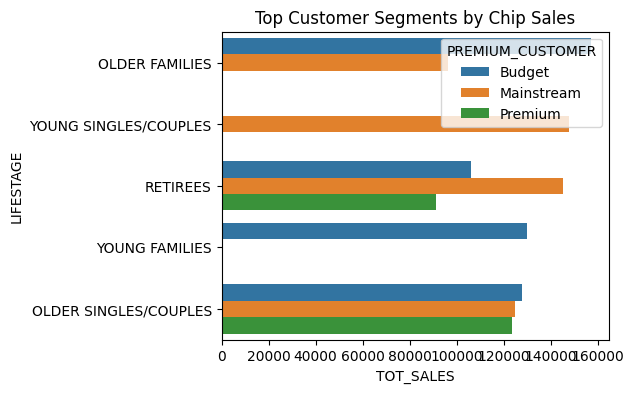

In [51]:
plt.figure(figsize=(5,4))
sns.barplot(data=segment_sales.sort_values("TOT_SALES", ascending=False).head(10),
            x="TOT_SALES", y="LIFESTAGE", hue="PREMIUM_CUSTOMER")
plt.title("Top Customer Segments by Chip Sales")
plt.show()


### 1.Highest Sales Segment
#### OLDER FAMILIES (Budget) generate the highest total chip sales among all customer segments.
### 2.Most Frequent Buyers
#### OLDER FAMILIES (Budget) and RETIREES (Mainstream) show the highest purchase frequency.
### 3.Strong Young Segment
#### YOUNG SINGLES/COUPLES (Mainstream) also contribute significantly to total sales and transaction count.
### 4.Pack Size Preference
#### Most customer segments prefer pack sizes around 175–180g.


### Recommendation:

#### The supermarket should prioritize OLDER FAMILIES (Budget) and YOUNG SINGLES/COUPLES (Mainstream) as key customer segments for chip promotions.
#### These segments contribute the highest sales and transaction volume. 
#### Promotions around 175g–180g pack sizes may perform well as this size is consistently preferred across segments.


In [38]:
customer_counts = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique().reset_index(name="CUSTOMERS")

segment_sales = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index()

sales_per_customer = segment_sales.merge(customer_counts, on=["LIFESTAGE","PREMIUM_CUSTOMER"])

sales_per_customer["SALES_PER_CUSTOMER"] = sales_per_customer["TOT_SALES"] / sales_per_customer["CUSTOMERS"]

sales_per_customer.sort_values("SALES_PER_CUSTOMER", ascending=False).head(10)


,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES,CUSTOMERS,SALES_PER_CUSTOMER
7,OLDER FAMILIES,Mainstream,96413.55,2788,34.581618
6,OLDER FAMILIES,Budget,156863.75,4611,34.019464
8,OLDER FAMILIES,Premium,75242.60,2231,33.725952
15,YOUNG FAMILIES,Budget,129717.95,3953,32.815065
17,YOUNG FAMILIES,Premium,78571.70,2398,32.765513
16,YOUNG FAMILIES,Mainstream,86338.25,2685,32.155773
11,OLDER SINGLES/COUPLES,Premium,123531.55,4682,26.384355
9,OLDER SINGLES/COUPLES,Budget,127833.60,4849,26.362879
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25,3298,25.692617
10,OLDER SINGLES/COUPLES,Mainstream,124648.50,4858,25.658399


#### Sales per customer analysis indicates that Older Families spend the most on average per customer across all premium categories. This suggests that this segment not only contributes large total sales but also demonstrates strong individual purchasing power in the chip category.

In [39]:
txn_per_customer = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"]).agg(
    TOTAL_TXN=("TXN_ID","count"),
    UNIQUE_CUSTOMERS=("LYLTY_CARD_NBR","nunique")
).reset_index()

txn_per_customer["TXN_PER_CUSTOMER"] = txn_per_customer["TOTAL_TXN"] / txn_per_customer["UNIQUE_CUSTOMERS"]

txn_per_customer.sort_values("TXN_PER_CUSTOMER", ascending=False).head(10)


,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_TXN,UNIQUE_CUSTOMERS,TXN_PER_CUSTOMER
7,OLDER FAMILIES,Mainstream,13241,2788,4.749283
6,OLDER FAMILIES,Budget,21514,4611,4.665799
8,OLDER FAMILIES,Premium,10403,2231,4.662931
17,YOUNG FAMILIES,Premium,10784,2398,4.497081
15,YOUNG FAMILIES,Budget,17763,3953,4.493549
16,YOUNG FAMILIES,Mainstream,11947,2685,4.449534
9,OLDER SINGLES/COUPLES,Budget,17172,4849,3.541349
11,OLDER SINGLES/COUPLES,Premium,16559,4682,3.536736
10,OLDER SINGLES/COUPLES,Mainstream,17061,4858,3.511939
1,MIDAGE SINGLES/COUPLES,Mainstream,11095,3298,3.364160


#### Transaction frequency analysis shows that Older Families and Young Families purchase chips more frequently than other customer segments. This suggests that these groups have a stronger habitual consumption pattern and represent a reliable base of repeat customers.

In [40]:
brand_sales = data.groupby("BRAND")["TOT_SALES"].sum().reset_index()

brand_sales = brand_sales.sort_values("TOT_SALES", ascending=False).head(10)
brand_sales


,BRAND,TOT_SALES
12,Kettle,390239.8
19,Smiths,202902.6
6,Doritos,187277.9
15,Pringles,177655.5
22,Thins,88852.5
24,Twisties,81522.1
23,Tostitos,79789.6
10,Infuzions,76247.6
4,Cobs,70569.8
16,RRD,64954.5


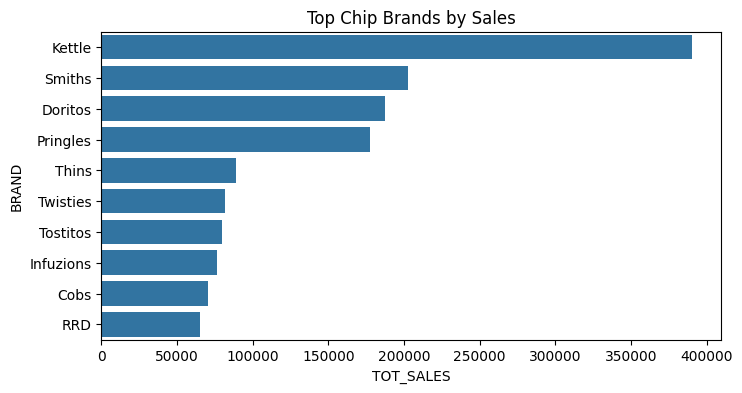

In [41]:
plt.figure(figsize=(8,4))
sns.barplot(data=brand_sales, x="TOT_SALES", y="BRAND")
plt.title("Top Chip Brands by Sales")
plt.show()


#### The chip category is strongly driven by a few dominant brands. Kettle leads the category with the highest sales, followed by Smiths, Doritos, and Pringles. These brands represent the core of category demand and likely have strong customer loyalty and shelf presence. Focusing promotional strategies on these leading brands may have the greatest impact on category growth.

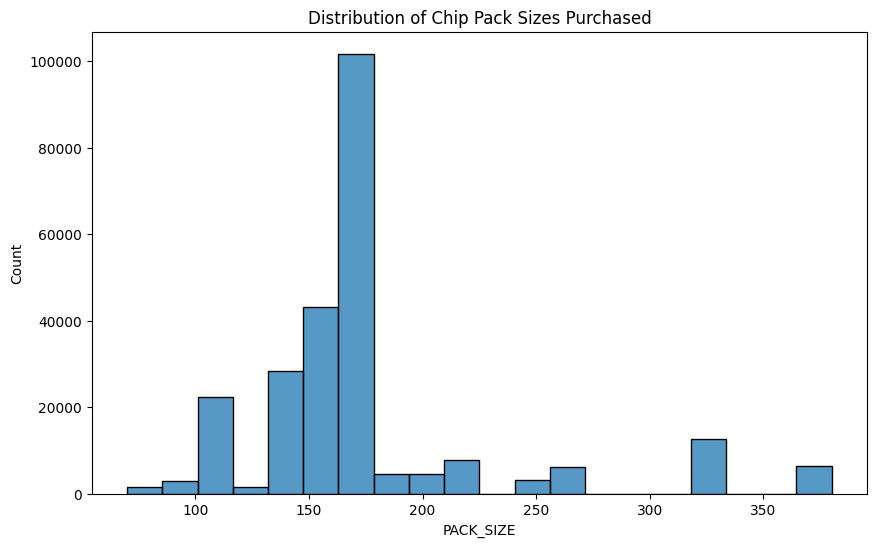

In [42]:
plt.figure(figsize=(10,6))
sns.histplot(data["PACK_SIZE"], bins=20)
plt.title("Distribution of Chip Pack Sizes Purchased")
plt.show()


#### The distribution of chip pack sizes shows that most purchases cluster around the 150g–180g range. This suggests that standard pack sizes dominate consumer preference. Larger pack sizes such as 330g and above appear less frequently, indicating that customers may prefer moderately sized packs for regular consumption.

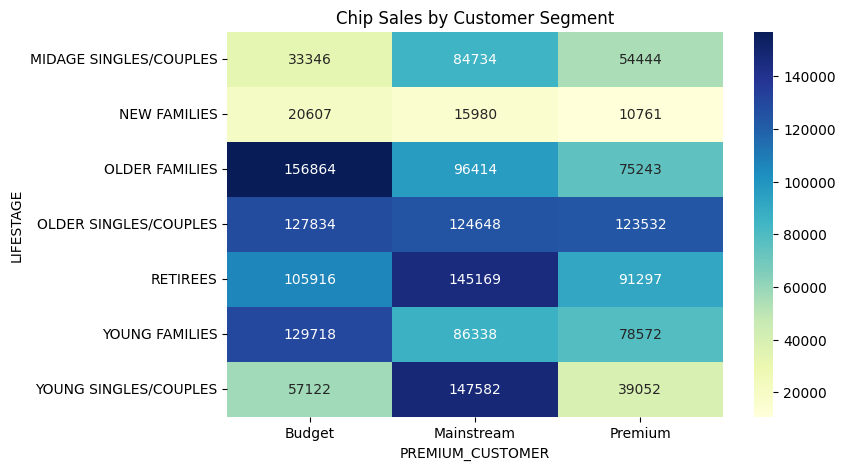

In [43]:
segment_matrix = data.pivot_table(
    values="TOT_SALES",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="sum"
)

plt.figure(figsize=(8,5))
sns.heatmap(segment_matrix, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Chip Sales by Customer Segment")
plt.show()


#### The heatmap highlights strong sales contributions from several key segments. Older Families (Budget) generate the highest total sales within the chip category, while Young Singles/Couples (Mainstream) and Retirees (Mainstream) also contribute significantly. These segments represent important customer groups for targeted marketing strategies.

In [44]:
brand_share = data.groupby("BRAND")["TOT_SALES"].sum()
brand_share = (brand_share / brand_share.sum()) * 100
brand_share = brand_share.sort_values(ascending=False).head(10)
brand_share


BRAND
Kettle       21.617877
Smiths       11.240072
Doritos      10.374520
Pringles      9.841474
Thins         4.922108
Twisties      4.516030
Tostitos      4.420056
Infuzions     4.223842
Cobs          3.909312
RRD           3.598245
Name: TOT_SALES, dtype: float64

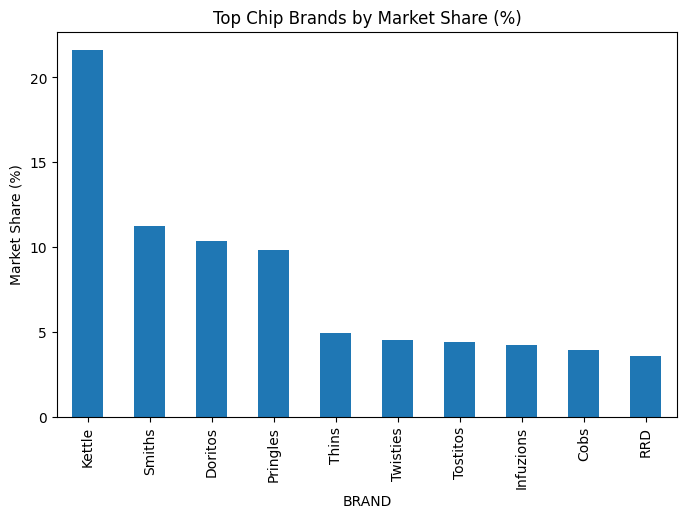

In [45]:
plt.figure(figsize=(8,5))
brand_share.plot(kind="bar")
plt.title("Top Chip Brands by Market Share (%)")
plt.ylabel("Market Share (%)")
plt.show()


### Brand Market Share Analysis
#### Insight
#### The market share analysis shows that the chip category is dominated by a few key brands. Kettle leads the category with approximately 21.6% of total chip sales, followed by Smiths (11.2%), Doritos (10.4%), and Pringles (9.8%). 
#### These four brands together account for a large portion of category revenue, indicating that the chip market is relatively concentrated among a few leading brands.


## Business Impact

#### Understanding brand market share helps category managers identify which brands have the strongest influence on overall category performance. 
#### If this analysis were not performed, we would only observe absolute sales values without understanding how dominant certain brands are within the market. Market share analysis highlights the competitive positioning of brands and helps guide decisions around promotions, shelf space allocation, and brand partnerships.


## Strategic Recommendation
#### Based on the analysis, the chip category is primarily driven by Older Families and Young Families across multiple spending and transaction metrics. These segments demonstrate both high total sales and strong purchase frequency, making them key drivers of category performance.

#### Additionally, Young Singles/Couples in the Mainstream segment contribute significantly to overall revenue and represent an important demographic for growth.

#### From a product perspective, standard pack sizes around 150g–180g dominate consumer purchasing behavior, suggesting that promotions and shelf placement strategies should prioritize these sizes.

#### Finally, leading brands such as Kettle, Smiths, Doritos, and Pringles account for a large portion of category sales, indicating that collaboration with these brands for promotional campaigns could further strengthen category performance.

## Conclusion
#### This analysis identified the key customer segments, product characteristics, and brand drivers influencing chip purchases. By focusing marketing and promotional strategies on high-performing customer segments and popular pack sizes, the supermarket can better position the chip category for growth in the upcoming review period.